# Tarea 5. Modelos lineales

<img style="float: right; margin: 0px 0px 15px 15px;" src="https://storage.needpix.com/rsynced_images/bayesian-2889576_1280.png" width="200px" height="180px" />

En esta quinta tarea, tendrás la oportunidad de estimar una relación cúbica usando un modelo lineal Bayesiano. Para esto usarás los datos en `data/Howell1`, considerando personas de todas las edades.

Por favor, intenta ser lo más explícit@ posible, y en lo posible, apóyate de la escritura matemática con $\LaTeX$.

Recuerda además que ante cualquier duda, me puedes contactar al correo esjimenezro@iteso.mx.

<p style="text-align:right;"> Imagen recuperada de: https://storage.needpix.com/rsynced_images/bayesian-2889576_1280.png.</p>

___

OWEN DAVID LOZA QUIRARTE

## 1. 

Describir el modelo usando el lenguaje probabilístico visto en clase. Asegurarse, mediante una simulación predictiva previa que las previas son plausibles.

**Ayuda**. Estandarizar el peso antes.

### Basándonos en lo que vimos en clase y en los notebooks del profe, el modelo quedaría así: 

$$
\begin{align}
\begin{array}{lcl}
h_i & \sim & \text{Normal}(\mu_i, \sigma) \\
\mu_i & = & \alpha + \beta_1 z_i + \beta_2 z_i^2 + \beta_3 z_i^3 \\
z_i & = & \dfrac{w_i - \bar{w}}{s_w} \\
\alpha & \sim & \text{Normal}(138, 20) \\
\beta_1 & \sim & \text{Log-Normal}(0, 1) \\
\beta_2 & \sim & \text{Normal}(0, 5) \\
\beta_3 & \sim & \text{Normal}(0, 5) \\
\sigma & \sim & \text{Uniform}(0, 50)
\end{array}
\end{align}
$$

donde $x_i = \frac{w_i - \bar{w}}{s_w}$ es el peso estandarizado.

porque? 

- alpha de (138, 20) -> altura esperada al peso promedio. Usamos 138 cm porque el dataset incluye personas de todas las edades ya sea de niños y adultos, por lo que la altura promedio es menor que en el modelo solo con adultos.
- beta_1 -> la relación principal peso/altura es positiva, por lo que restringimos $\beta_1 > 0$, igual que en clase.
- beta_2 y beta_3 -> los términos de curvatura pueden ser positivos o negativos, por lo que usamos previas simétricas débiles centradas en cero.
- sigma -> igual que en clase, restringimos la desviación estándar a ser positiva y acotada.

In [24]:
import pandas as pd
import numpy as np
from scipy import stats
from matplotlib import pyplot as plt
import pymc as pm
import arviz as az

df = pd.read_csv('data/Howell1.csv', sep=';')
df

,height,weight,age,male
0,151.765,47.825606,63.0,1
1,139.700,36.485807,63.0,0
2,136.525,31.864838,65.0,0
3,156.845,53.041914,41.0,1
4,145.415,41.276872,51.0,0
...,...,...,...,...
539,145.415,31.127751,17.0,1
540,162.560,52.163080,31.0,1
541,156.210,54.062497,21.0,0
542,71.120,8.051258,0.0,1


In [25]:
# Ahora vamos a estandarizar el peso
w = df['weight'].values
h = df['height'].values
w_bar = w.mean()
w_std = w.std()
# Peso estandarizado
z = (w - w_bar) / w_std


# Definimos nuestras previas
alpha = stats.norm(loc=138, scale=20)
beta1 = stats.lognorm(s=1, scale=np.exp(0)) 
beta2 = stats.norm(loc=0, scale=5)
beta3 = stats.norm(loc=0, scale=5)
sigma = stats.uniform(loc=0, scale=50)

In [26]:
# ahora hacemos la simulación predictiva previa
n_samples = 200
z_sorted = np.sort(z)
# muestras de las previas
alpha_samples = alpha.rvs(size=n_samples)
beta1_samples = beta1.rvs(size=n_samples)
beta2_samples = beta2.rvs(size=n_samples)
beta3_samples = beta3.rvs(size=n_samples)
# curvas de mu
mu_samples = (
    alpha_samples[:, np.newaxis]
    + beta1_samples[:, np.newaxis] * z_sorted
    + beta2_samples[:, np.newaxis] * z_sorted**2
    + beta3_samples[:, np.newaxis] * z_sorted**3
)

C:\Users\oweno\AppData\Local\Temp\ipykernel_17564\432017761.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


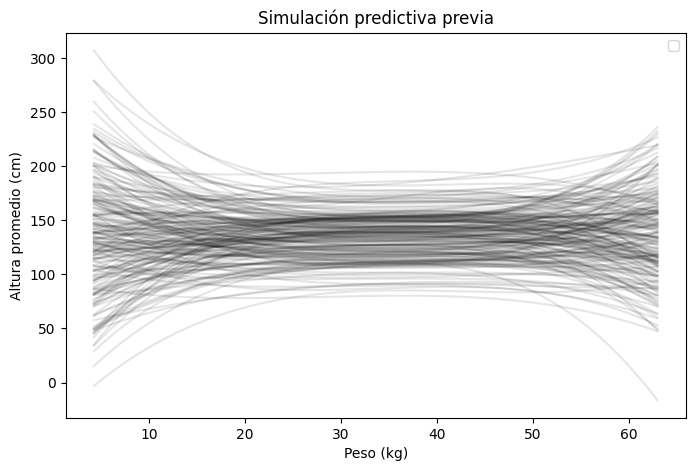

In [27]:
# pasamos z de vuelta a kilos para que sea interpretable
w_sorted = z_sorted * w_std + w_bar
# graficamos 
plt.figure(figsize=(8, 5))
plt.plot(w_sorted, mu_samples.T, 'k', alpha=0.1)
plt.xlabel('Peso (kg)')
plt.ylabel('Altura promedio (cm)')
plt.title('Simulación predictiva previa')
plt.legend()
plt.show()

## 2.

Encontrar la distribución posterior de los parámetros. ¿Qué puede concluir de cada uno de ellos?

In [ ]:
# Definimos el modelo
with pm.Model() as cubic_height_model:
    alpha = pm.Normal('alpha', mu=138, sigma=20)
    beta1 = pm.Lognormal('beta1', mu=0, sigma=1)
    beta2 = pm.Normal('beta2', mu=0, sigma=5)
    beta3 = pm.Normal('beta3', mu=0, sigma=5)
    sigma = pm.Uniform('sigma', lower=0, upper=50)
    # Media
    mu = alpha + beta1 * z + beta2 * z**2 + beta3 * z**3
    # Verosimilitud
    height = pm.Normal('height', mu=mu, sigma=sigma, observed=h)

In [29]:
# Muestreo de la posterior con MCMC
with cubic_height_model:
    idata = pm.sample()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta1, beta2, beta3, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3784 seconds.


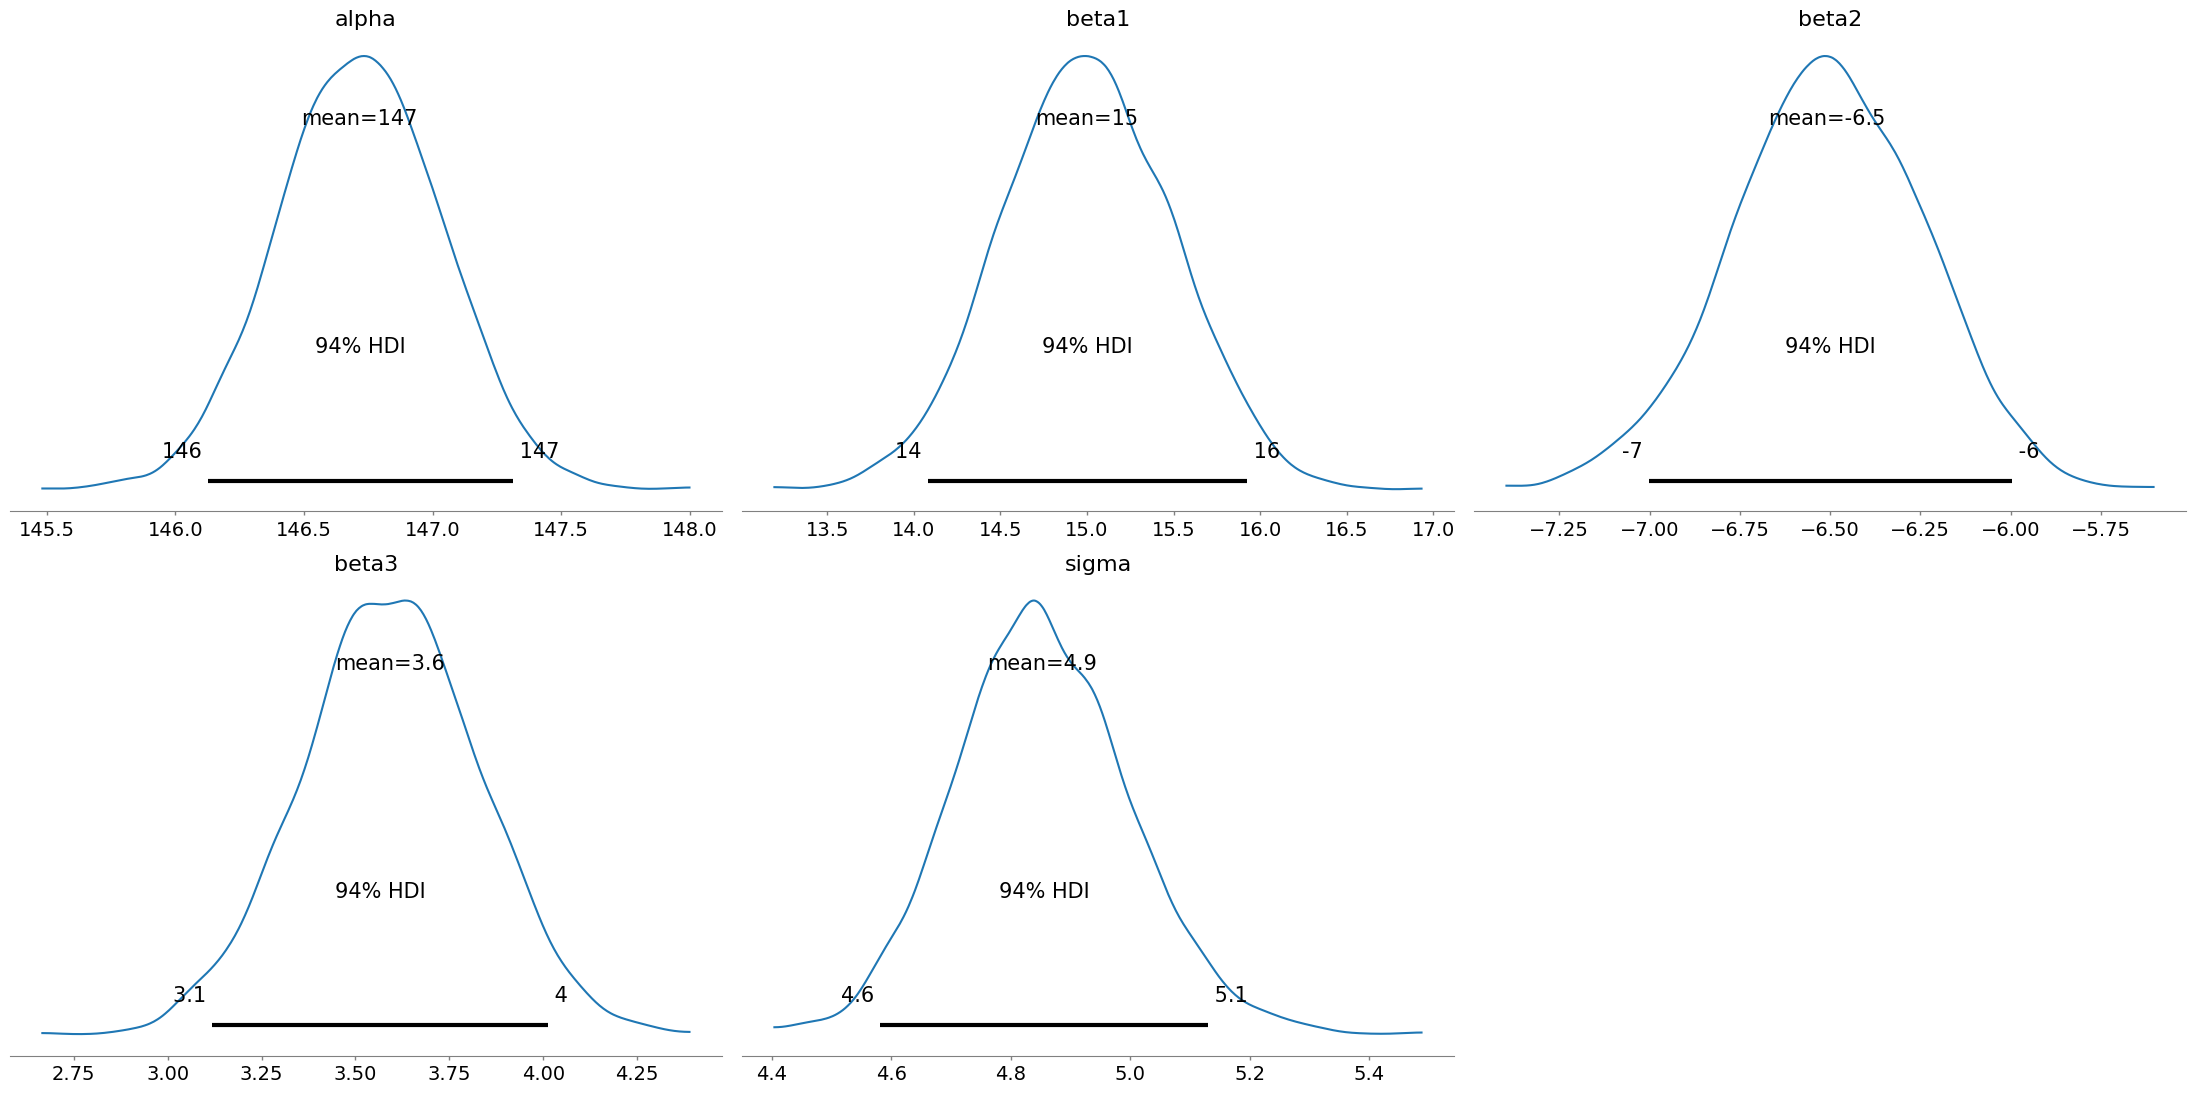

In [30]:
# vemos las posteriores graficadas
az.plot_posterior(idata, var_names=['alpha', 'beta1', 'beta2', 'beta3', 'sigma'])
plt.tight_layout()
plt.show()

In [31]:
az.summary(idata, var_names=['alpha', 'beta1', 'beta2', 'beta3', 'sigma'], hdi_prob=0.89)

,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,146.715,0.320,146.191,147.207,0.007,0.005,2012.0,2427.0,1.0
beta1,14.998,0.496,14.240,15.815,0.011,0.008,2140.0,2227.0,1.0
beta2,-6.508,0.266,-6.924,-6.079,0.006,0.004,2320.0,2361.0,1.0
beta3,3.592,0.236,3.233,3.985,0.005,0.004,1971.0,2242.0,1.0
sigma,4.852,0.147,4.622,5.090,0.003,0.003,3142.0,2598.0,1.0


### Conclusiones sobre cada parámetro

A partir de las distribuciones posteriores, y leyendo el resumen numérico HDI al 89%:

- **$\alpha \approx 146.7$ cm:**
  Es la altura que se espera para alguien que pese lo promedio de la población. Como los datos incluyen niños y adultos, ese "peso promedio" es de unos 35 kg, así que esta altura corresponde más o menos a la de un adolescente. El HDI es súper angosto (apenas ~1 cm), o sea que el modelo tiene mucha confianza sobre este valor.

- **$\beta_1 \approx 15.0$:**
  Es el efecto principal del peso sobre la altura. Es positivo y el HDI no toca el cero, así que está claro que **a más peso, más altura**. La interpretación: por cada desviación estándar que aumenta el peso (~14.7 kg), la altura sube alrededor de 15 cm.

- **$\beta_2 \approx -6.5$:**
  Este es el término cuadrático y salió **negativo** (todo el HDI está por debajo de cero). Esto hace que la curva se "doble hacia abajo": significa que **ganar peso aporta cada vez menos altura conforme la persona crece**. Es justo lo que se ve en el scatter — la curva se aplana en pesos altos.

- **$\beta_3 \approx 3.6$:**
  El término cúbico salió **positivo** y el HDI tampoco incluye al cero. Este término le da la forma de "S" a la curva, que es justo lo que necesitamos para modelar bien tanto a niños (donde la altura crece rapidísimo con el peso) como a adultos (donde se estabiliza).

- **$\sigma \approx 4.85$ cm:**
  Es qué tanto se desvían las alturas reales de la línea promedio. Una persona típica está a ~5 cm de lo que predice el modelo. Considerando que las alturas van de 54 a 179 cm, una desviación de 5 cm es chiquita, lo que indica que el modelo cúbico **ajusta muy bien** los datos.


## 3.

¿Cuál es la distribución de la altura promedio de un infante de 10kg según tu modelo y los datos?

In [43]:
# Estandarizar el peso de 10 kg con la media y std del entrenamiento
w_infant = 10
z_infant = (w_infant - w_bar) / w_std

# Extraer muestras de la posterior de cada parámetro
alpha_samples = idata.posterior['alpha'].values.flatten()
beta1_samples = idata.posterior['beta1'].values.flatten()
beta2_samples = idata.posterior['beta2'].values.flatten()
beta3_samples = idata.posterior['beta3'].values.flatten()

# Calcular la distribución posterior de mu en w = 10 kg
mu_at_10 = (
    alpha_samples
    + beta1_samples * z_infant
    + beta2_samples * z_infant**2
    + beta3_samples * z_infant**3
)

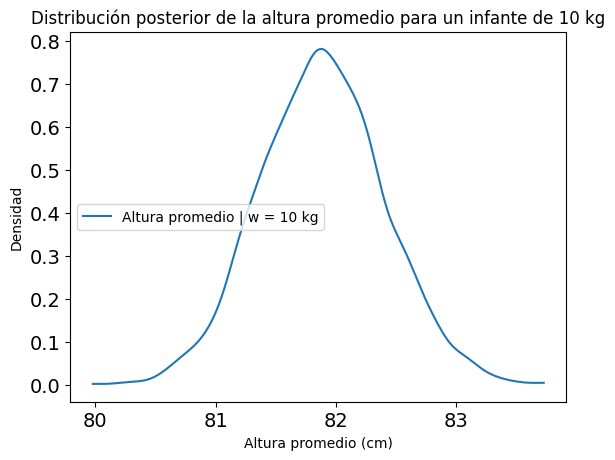

In [44]:
# Visualizar la distribución posterior de la altura promedio
az.plot_kde(mu_at_10, label='Altura promedio | w = 10 kg')
plt.xlabel('Altura promedio (cm)')
plt.ylabel('Densidad')
plt.title('Distribución posterior de la altura promedio para un infante de 10 kg')
plt.legend()
plt.show()

In [45]:
# Resumen: media e HDI al 89%
print(f"Media:     {mu_at_10.mean():.2f} cm")
print(f"HDI 89%:   {az.hdi(mu_at_10, hdi_prob=0.89)} cm")


Media:     81.88 cm
HDI 89%:   [81.09266055 82.7261162 ] cm


## 4.

Graficar:

- El intervalo de credibilidad al 89% de la altura para cada peso.
- El intervalo de credibilidad al 89% de la altura promedio para cada peso.
- La altura promedio para cada peso.
- Los puntos correspondientes a cada individuo.

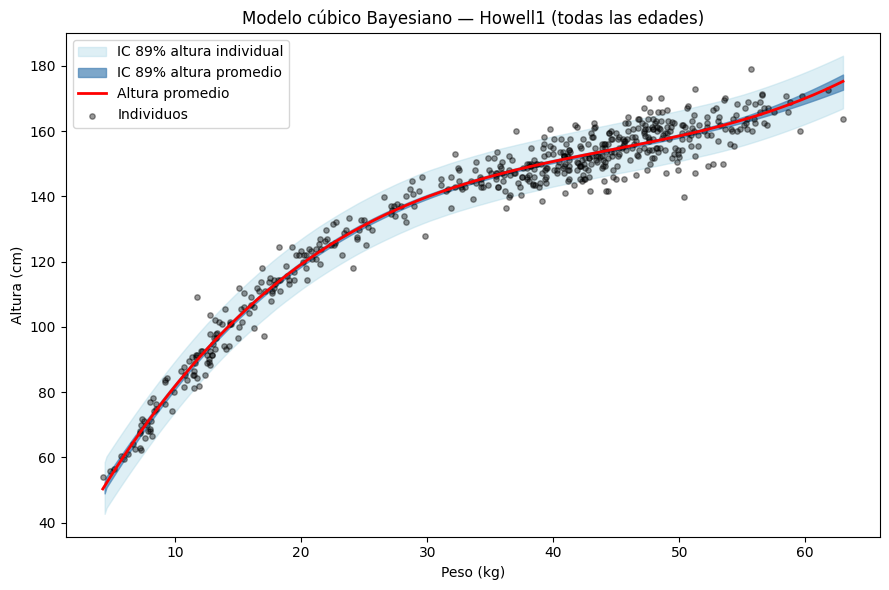

In [48]:
# vector de pesos para graficar
w_plot = np.linspace(df['weight'].min(), df['weight'].max(), 200)
z_plot = (w_plot - w_bar) / w_std

# extraer muestras de sigma 
sigma_samples = idata.posterior['sigma'].values.flatten()

# distribución posterior de mu que es la altura promedio para cada peso
mu_samples = (
    alpha_samples[:, None]
    + beta1_samples[:, None] * z_plot
    + beta2_samples[:, None] * z_plot**2
    + beta3_samples[:, None] * z_plot**3
)

# distribución predictiva posterior de la altura individual
h_pred = np.random.normal(loc=mu_samples, scale=sigma_samples[:, None])

# gráfico
fig, ax = plt.subplots(figsize=(9, 6))

# intervalo 89% de la altura individual
az.plot_hdi(w_plot, h_pred, hdi_prob=0.89, color='lightblue',
            fill_kwargs={'alpha': 0.4, 'label': 'IC 89% altura individual'}, ax=ax)

# intervalo 89% de la altura promedio
az.plot_hdi(w_plot, mu_samples, hdi_prob=0.89, color='steelblue',
            fill_kwargs={'alpha': 0.7, 'label': 'IC 89% altura promedio'}, ax=ax)

# la altura promedio 
ax.plot(w_plot, mu_samples.mean(axis=0), 'r-', lw=2, label='Altura promedio')

# nuestros datos observados 
ax.scatter(df['weight'], df['height'],
           alpha=0.4, s=15, color='black', label='Individuos')

ax.set_xlabel('Peso (kg)')
ax.set_ylabel('Altura (cm)')
ax.set_title('Modelo cúbico Bayesiano — Howell1 (todas las edades)')
ax.legend()
plt.tight_layout()
plt.show()

<script>
  $(document).ready(function(){
    $('div.prompt').hide();
    $('div.back-to-top').hide();
    $('nav#menubar').hide();
    $('.breadcrumb').hide();
    $('.hidden-print').hide();
  });
</script>

<footer id="attribution" style="float:right; color:#808080; background:#fff;">
Created with Jupyter by Esteban Jiménez Rodríguez.
</footer>